In [9]:
import pandas as pd
import numpy as np

# Reproducible data
np.random.seed(42)

# 365 days weather data
dates = pd.date_range(start="2025-01-01", periods=365, freq="D")

temperature = np.random.normal(25, 7, 365).round(1)
humidity = np.random.randint(35, 95, 365)
pressure = np.random.normal(1013, 8, 365).round(1)
wind_speed = np.random.uniform(2, 25, 365).round(1)
rainfall = np.maximum(
    0,
    np.random.normal(4, 8, 365)
).round(1)

# Weather condition
weather = []

for i in range(365):
    if rainfall[i] > 10 and humidity[i] > 70:
        weather.append("Rainy")
    elif humidity[i] > 75:
        weather.append("Cloudy")
    else:
        weather.append("Sunny")

# Create DataFrame
df = pd.DataFrame({
    "Date": dates,
    "Temperature": temperature,
    "Humidity": humidity,
    "Pressure": pressure,
    "WindSpeed": wind_speed,
    "Rainfall": rainfall,
    "Weather": weather
})

# Save dataset
df.to_csv("weather_data.csv", index=False)

# Show first 5 rows
df.head()

,Date,Temperature,Humidity,Pressure,WindSpeed,Rainfall,Weather
0,2025-01-01,28.5,72,1009.8,15.0,15.1,Rainy
1,2025-01-02,24.0,87,1013.2,8.1,8.5,Cloudy
2,2025-01-03,29.5,40,1014.0,22.2,8.8,Sunny
3,2025-01-04,35.7,92,1010.1,20.3,10.8,Rainy
4,2025-01-05,23.4,78,1011.1,17.1,10.1,Rainy


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         365 non-null    datetime64[ns]
 1   Temperature  365 non-null    float64       
 2   Humidity     365 non-null    int32         
 3   Pressure     365 non-null    float64       
 4   WindSpeed    365 non-null    float64       
 5   Rainfall     365 non-null    float64       
 6   Weather      365 non-null    object        
dtypes: datetime64[ns](1), float64(4), int32(1), object(1)
memory usage: 18.7+ KB


In [11]:
df.describe()

,Date,Temperature,Humidity,Pressure,WindSpeed,Rainfall
count,365,365.000000,365.000000,365.000000,365.000000,365.000000
mean,2025-07-01 23:59:59.999999744,25.070959,65.076712,1012.390411,13.718356,6.003014
min,2025-01-01 00:00:00,2.300000,35.000000,985.200000,2.100000,0.000000
25%,2025-04-02 00:00:00,20.400000,50.000000,1006.700000,7.700000,0.000000
50%,2025-07-02 00:00:00,25.400000,65.000000,1012.400000,14.000000,4.500000
75%,2025-10-01 00:00:00,29.400000,81.000000,1017.900000,19.300000,9.700000
max,2025-12-31 00:00:00,52.000000,94.000000,1035.300000,25.000000,24.800000
std,NaN,6.634743,17.578072,8.334154,6.731186,6.149972


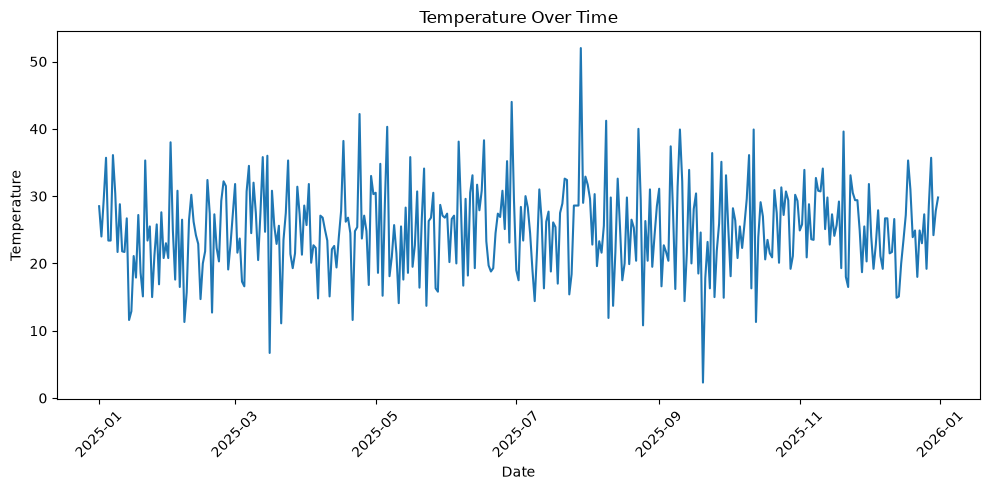

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df["Date"], df["Temperature"])
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("Temperature Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

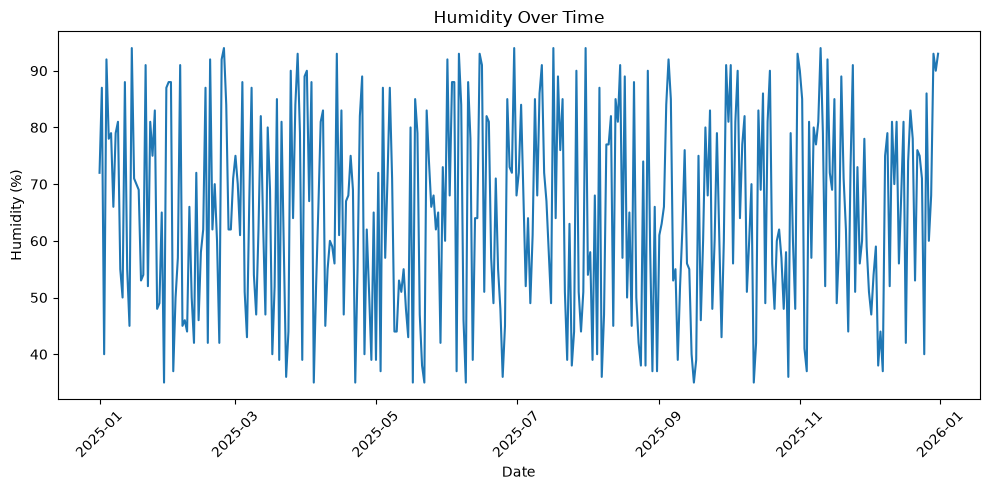

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(df["Date"], df["Humidity"])
plt.xlabel("Date")
plt.ylabel("Humidity (%)")
plt.title("Humidity Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

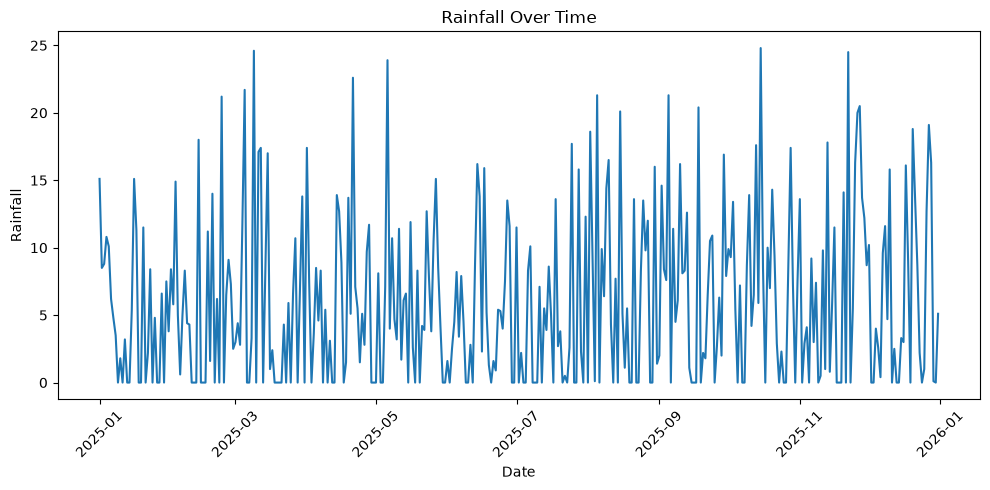

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(df["Date"], df["Rainfall"])
plt.xlabel("Date")
plt.ylabel("Rainfall")
plt.title("Rainfall Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

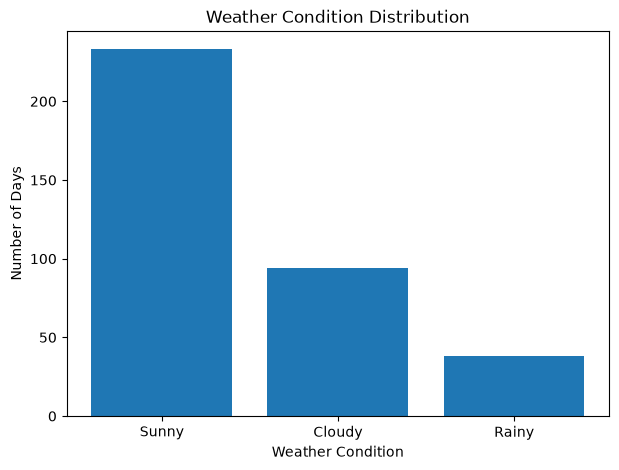

In [16]:
weather_counts = df["Weather"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(weather_counts.index, weather_counts.values)
plt.xlabel("Weather Condition")
plt.ylabel("Number of Days")
plt.title("Weather Condition Distribution")
plt.show()



In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Features
X = df[["Temperature", "Humidity", "Pressure", "WindSpeed", "Rainfall"]]

# Target
y = df["Weather"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (292, 5)
Testing data: (73, 5)


In [18]:
# Create and train the model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Model training completed!")

✅ Model training completed!


In [19]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 98.63 %


In [20]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.95      1.00      0.97        19
       Rainy       1.00      0.88      0.93         8
       Sunny       1.00      1.00      1.00        46

    accuracy                           0.99        73
   macro avg       0.98      0.96      0.97        73
weighted avg       0.99      0.99      0.99        73



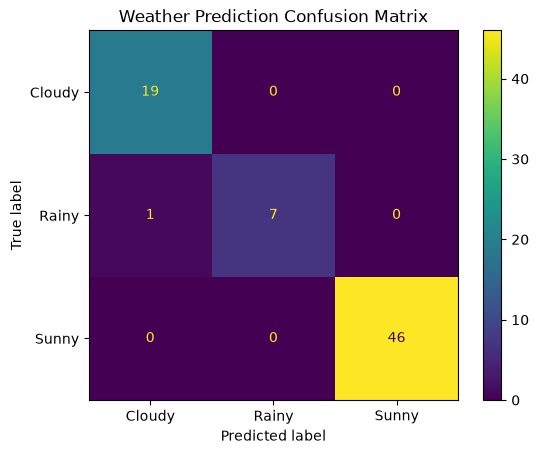

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Weather Prediction Confusion Matrix")
plt.show()

In [22]:
# Live Weather Prediction

temperature = float(input("Enter Temperature: "))
humidity = float(input("Enter Humidity: "))
pressure = float(input("Enter Pressure: "))
wind_speed = float(input("Enter Wind Speed: "))
rainfall = float(input("Enter Rainfall: "))

new_data = pd.DataFrame({
    "Temperature": [temperature],
    "Humidity": [humidity],
    "Pressure": [pressure],
    "WindSpeed": [wind_speed],
    "Rainfall": [rainfall]
})

prediction = model.predict(new_data)

print("🌦️ Predicted Weather:", prediction[0])

🌦️ Predicted Weather: Sunny
